# Geometric Brownian motion paths

Simulate **10,000 paths by default** using the exact GBM transition:

$$\log(S_{t+\Delta t}/S_t) = (\mu - \sigma^2/2)\Delta t + \sigma\sqrt{\Delta t}\,Z, \qquad Z\sim N(0,1).$$

`mu` and `sigma` are annualized price drift and volatility. Each step is one day,
with `dt = 1 / days_per_year`. The default uses 365 calendar days per year;
use 252 for trading days. These are illustrative parameters, not fitted estimates.

The plot shows **cumulative log return** $\log(S_t/S_0)$, not individual daily
returns. The cyan dashed line is its theoretical expectation
$(\mu-\sigma^2/2)t$.


In [1]:
from numbers import Integral

import matplotlib.pyplot as plt
import numpy as np


In [2]:
def simulate_gbm(
    n_paths=10_000,
    n_days=365,
    mu=0.04,
    sigma=0.20,
    initial_price=100.0,
    days_per_year=365,
    seed=None,
):
    """Return (days, prices, cumulative_log_returns).

    Both path arrays have shape (n_days + 1, n_paths), including day zero.
    A fixed seed reproduces the paths without changing NumPy's global RNG.
    """
    for name, value in (("n_paths", n_paths), ("n_days", n_days)):
        if isinstance(value, bool) or not isinstance(value, Integral) or value < 1:
            raise ValueError(f"{name} must be a positive integer")
    if not np.isfinite(mu):
        raise ValueError("mu must be finite")
    if not np.isfinite(sigma) or sigma < 0:
        raise ValueError("sigma must be finite and nonnegative")
    if not np.isfinite(initial_price) or initial_price <= 0:
        raise ValueError("initial_price must be finite and positive")
    if not np.isfinite(days_per_year) or days_per_year <= 0:
        raise ValueError("days_per_year must be finite and positive")

    rng = np.random.default_rng(seed)
    dt = 1.0 / days_per_year
    increments = rng.normal(
        loc=(mu - 0.5 * sigma**2) * dt,
        scale=sigma * np.sqrt(dt),
        size=(n_days, n_paths),
    )
    log_returns = np.zeros((n_days + 1, n_paths))
    np.cumsum(increments, axis=0, out=log_returns[1:])
    prices = initial_price * np.exp(log_returns)
    return np.arange(n_days + 1), prices, log_returns


## Simulation parameters

Change `n_paths` to control how many paths are simulated and plotted.


In [3]:
n_paths = 10_000
n_days = 365
mu = 0.04
sigma = 0.20
initial_price = 100.0
days_per_year = 365
seed = 42

days, prices, log_returns = simulate_gbm(
    n_paths=n_paths,
    n_days=n_days,
    mu=mu,
    sigma=sigma,
    initial_price=initial_price,
    days_per_year=days_per_year,
    seed=seed,
)


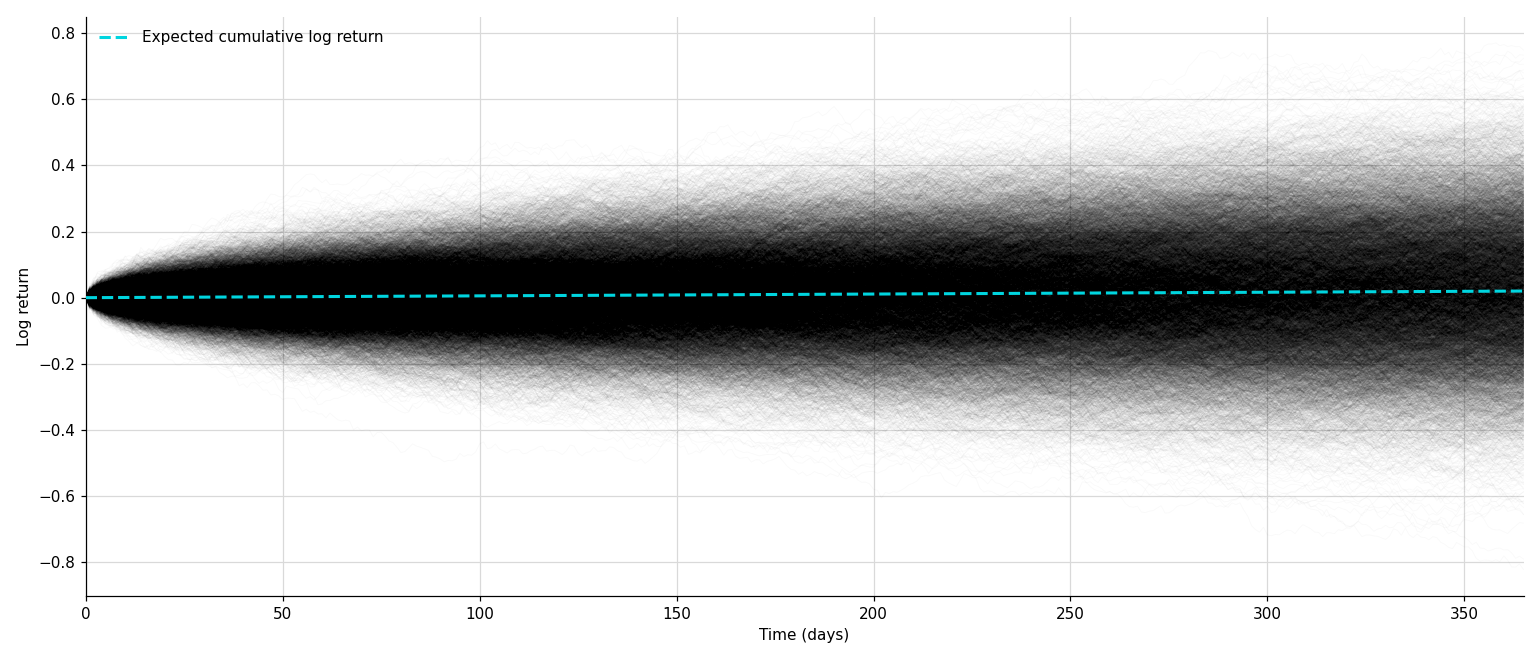

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(days, log_returns, color="black", alpha=0.025, linewidth=0.6,
        rasterized=True)
expected_log_return = (mu - 0.5 * sigma**2) * days / days_per_year
ax.plot(days, expected_log_return, color="#00d5df", linestyle="--",
        linewidth=2, label="Expected cumulative log return", zorder=3)
ax.set(xlabel="Time (days)", ylabel="Log return", xlim=(0, n_days))
ax.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## Terminal distribution: simulation versus theory

For the simulated horizon $T = n_{days}/days_{per\ year}$, the terminal
cumulative log return has distribution

$$R_T = \log(S_T/S_0) \sim \mathcal{N}\left((\mu-\sigma^2/2)T,\;\sigma^2 T\right).$$

Compare the **last observation of each independent path** with this normal law.
The histogram uses probability density (`density=True`), so its total area is
one. The cyan curve uses the simulation parameters directly, without fitting
the observed sample. Prices themselves have a lognormal distribution.

This analysis reuses all `n_paths` paths above. Increase that parameter for a
smoother histogram. The horizontal scale depends on the chosen horizon and
volatility, so a full-year distribution is wider than a daily distribution.


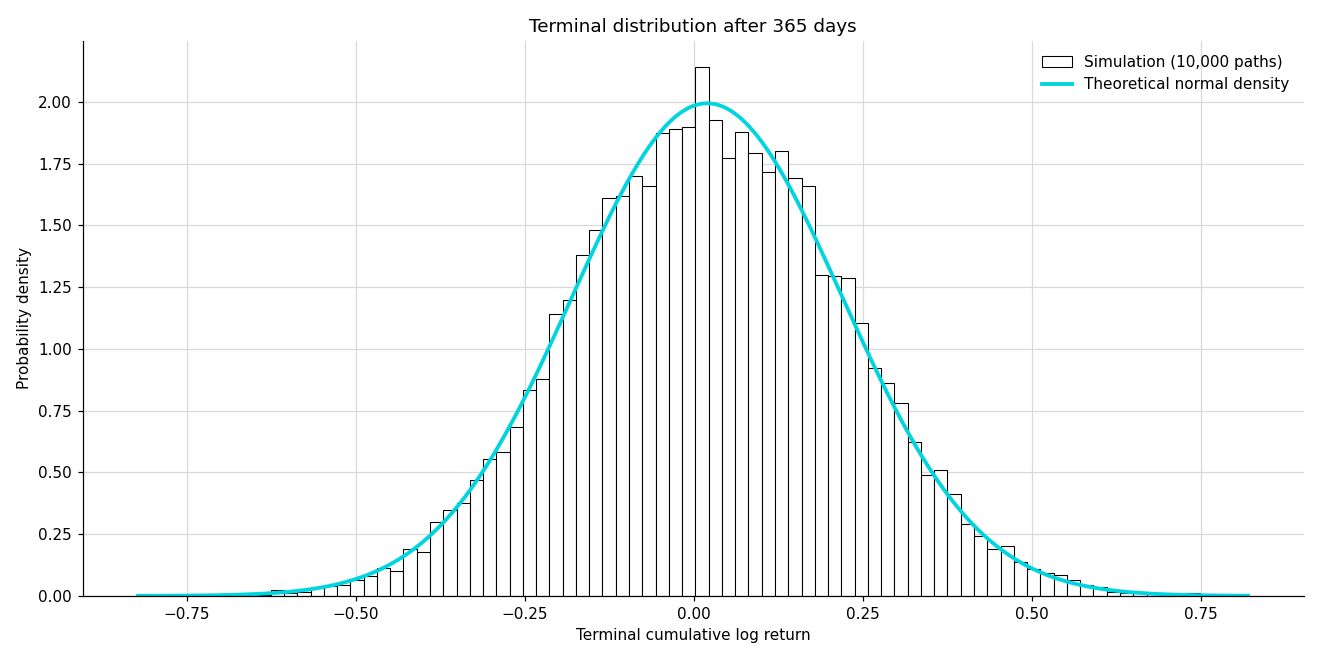

In [5]:
terminal_returns = log_returns[-1]
terminal_count = terminal_returns.size
horizon_years = days[-1] / days_per_year
theoretical_mean = (mu - 0.5 * sigma**2) * horizon_years
theoretical_variance = sigma**2 * horizon_years
theoretical_std = np.sqrt(theoretical_variance)

fig_distribution, ax_distribution = plt.subplots(figsize=(12, 6))
if theoretical_std > 0:
    ax_distribution.hist(
        terminal_returns, bins=80, density=True,
        facecolor="white", edgecolor="black", linewidth=0.7,
        label=f"Simulation ({terminal_count:,} paths)",
    )
    x = np.linspace(
        min(terminal_returns.min(), theoretical_mean - 4 * theoretical_std),
        max(terminal_returns.max(), theoretical_mean + 4 * theoretical_std),
        1000,
    )
    theoretical_density = np.exp(
        -0.5 * ((x - theoretical_mean) / theoretical_std)**2
    ) / (theoretical_std * np.sqrt(2 * np.pi))
    ax_distribution.plot(
        x, theoretical_density, color="#00d5df", linewidth=2.5,
        label="Theoretical normal density",
    )
    ax_distribution.set_ylabel("Probability density")
else:
    # With zero volatility the distribution is a point mass, not a normal PDF.
    ax_distribution.axvline(terminal_returns.mean(), color="black",
                            linewidth=3, label="Simulated terminal return")
    ax_distribution.axvline(theoretical_mean, color="#00d5df", linestyle="--",
                            linewidth=2, label="Theoretical point mass")
    ax_distribution.set_yticks([])
    ax_distribution.set_ylabel("Point mass (no continuous density)")
ax_distribution.set_xlabel("Terminal cumulative log return")
ax_distribution.set_title(f"Terminal distribution after {days[-1]:,} days")
ax_distribution.grid(True, color="0.85", linewidth=0.8)
ax_distribution.set_axisbelow(True)
ax_distribution.spines[["top", "right"]].set_visible(False)
ax_distribution.legend(frameon=False)
fig_distribution.tight_layout()
plt.show()


In [6]:
empirical_mean = terminal_returns.mean()
empirical_variance = terminal_returns.var(ddof=1) if terminal_count > 1 else np.nan

print(f"{'Statistic':<22} {'Simulated':>14} {'Theoretical':>14}")
print(f"{'Mean':<22} {empirical_mean:>14.6f} {theoretical_mean:>14.6f}")
print(f"{'Sample variance':<22} {empirical_variance:>14.6f} {theoretical_variance:>14.6f}")
print(f"{'Standard deviation':<22} {np.sqrt(empirical_variance):>14.6f} {theoretical_std:>14.6f}")

if theoretical_std > 0 and terminal_count > 1:
    mean_se = theoretical_std / np.sqrt(terminal_count)
    variance_se = theoretical_variance * np.sqrt(2 / (terminal_count - 1))
    mean_error_se = (empirical_mean - theoretical_mean) / mean_se
    variance_error_se = (empirical_variance - theoretical_variance) / variance_se
    central_coverage = np.mean(
        np.abs(terminal_returns - theoretical_mean) <= 1.959963984540054 * theoretical_std
    )
    print(f"\nMean error / Monte Carlo standard error: {mean_error_se:.2f}")
    print(f"Variance error / Monte Carlo standard error: {variance_error_se:.2f}")
    print(f"Within theoretical central 95% interval: {central_coverage:.2%} (expected 95%)")
elif theoretical_std == 0:
    print(f"\nMaximum absolute deviation from point mass: "
          f"{np.max(np.abs(terminal_returns - theoretical_mean)):.3g}")
else:
    print("\nAt least two paths are needed for sample variance and error diagnostics.")


Statistic                   Simulated    Theoretical
Mean                         0.023235       0.020000
Sample variance              0.040378       0.040000
Standard deviation           0.200942       0.200000

Mean error / Monte Carlo standard error: 1.62
Variance error / Monte Carlo standard error: 0.67
Within theoretical central 95% interval: 95.06% (expected 95%)


### Reading the comparison

Agreement between the bars and cyan curve, close mean and variance, and about
95% of endpoints inside the theoretical central interval support the simulation.
The numerical diagnostics express mean and variance errors in Monte Carlo
standard errors under the theoretical model. Errors of roughly two standard
errors or less are typical; larger deviations can still happen by chance.
The variance error is only approximately normal for large samples.

These are sanity checks, not proof of distributional equality. Increasing the
number of independent paths generally reduces sampling error. A terminal
histogram alone also cannot verify dependence or transitions along each path.
